# Global Fuel Price Trends (1970–2026)

- Long-term oil price analysis
- Crisis detection (oil shocks, 2008, COVID)
- Volatility & trend analysis
- Forecasting future prices

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
plt.style.use("ggplot")

In [17]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\fuel_prices_1970_2026.csv")  
df.head()

,Date,Crude_Oil_Price
0,1970-01-01,1.21
1,1970-02-01,1.21
2,1970-03-01,1.21
3,1970-04-01,1.21
4,1970-05-01,1.21


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 675 entries, 0 to 674
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             675 non-null    str    
 1   Crude_Oil_Price  675 non-null    float64
dtypes: float64(1), str(1)
memory usage: 10.7 KB


In [19]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.head()

,Date,Crude_Oil_Price
0,1970-01-01,1.21
1,1970-02-01,1.21
2,1970-03-01,1.21
3,1970-04-01,1.21
4,1970-05-01,1.21


In [20]:
print(df.shape)
df.describe()

(675, 2)


,Date,Crude_Oil_Price
count,675,675.000000
mean,1998-01-30 14:47:28,39.804040
min,1970-01-01 00:00:00,1.210000
25%,1984-01-16 12:00:00,16.533333
50%,1998-02-01 00:00:00,29.113333
75%,2012-02-15 12:00:00,61.246667
max,2026-03-01 00:00:00,132.825184
std,NaN,30.611456


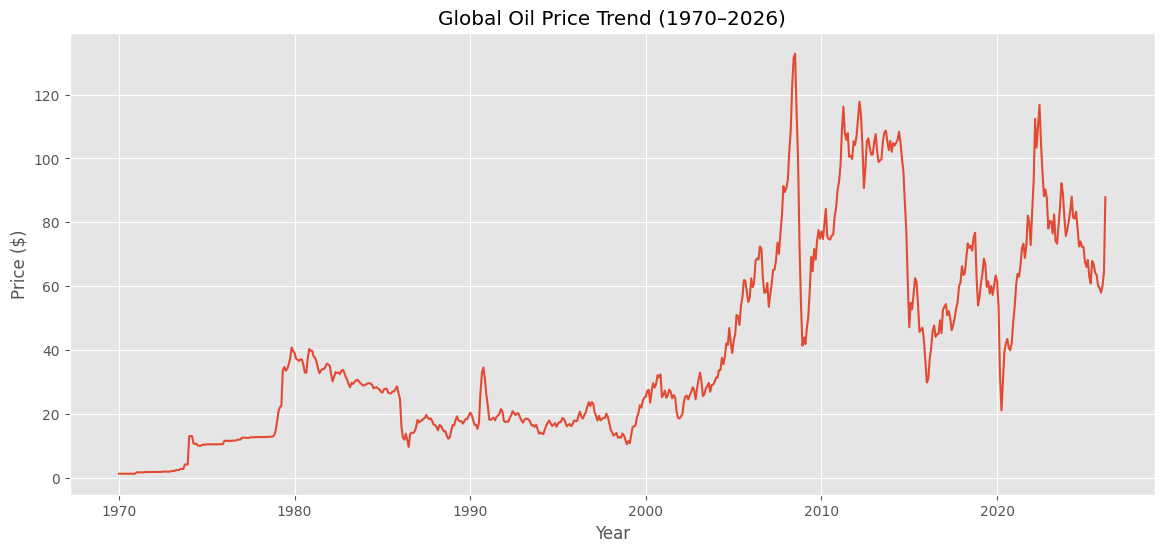

In [ ]:
# Oil Price Trends from 1970 to 2026
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Crude_Oil_Price"])
plt.title("Global Oil Price Trend (1970–2026)")
plt.xlabel("Year")
plt.ylabel("Price ($)")
plt.show()

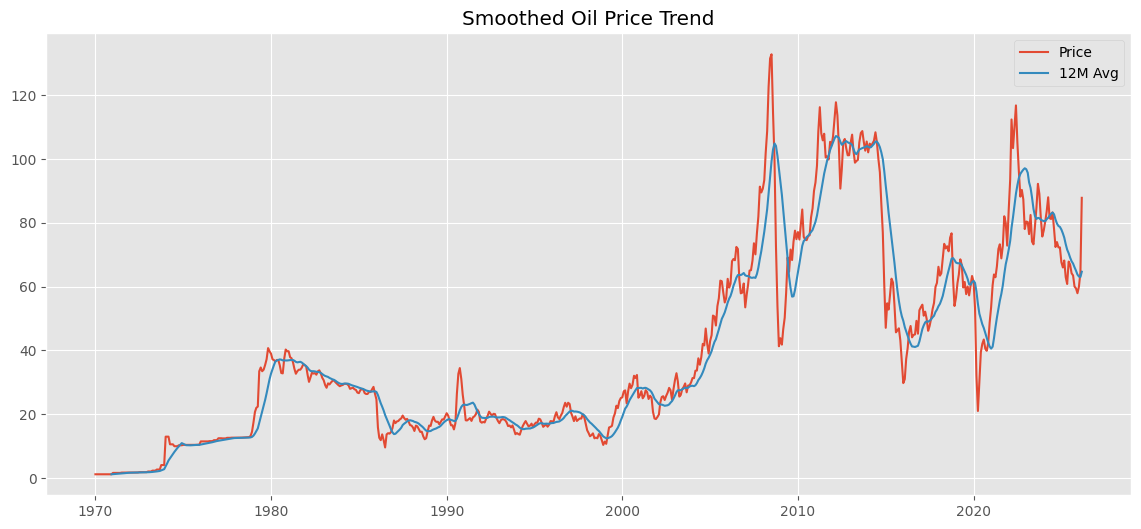

In [ ]:
# Average Oil Price Trends and Normal Price Trends by Year 
df["MA_12"] = df["Crude_Oil_Price"].rolling(12).mean()
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Crude_Oil_Price"], label="Price")
plt.plot(df["Date"], df["MA_12"], label="12M Avg")
plt.legend()
plt.title("Smoothed Oil Price Trend")
plt.show()

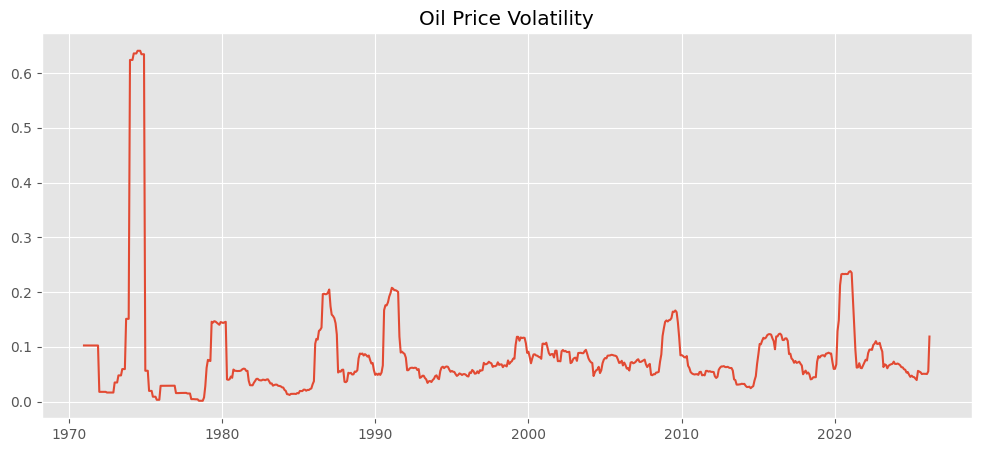

In [32]:
# The percentage change between current and previous oil prices.
df["volatility"] = df["Crude_Oil_Price"].pct_change().rolling(12).std()
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["volatility"])
plt.title("Oil Price Volatility")
plt.show()

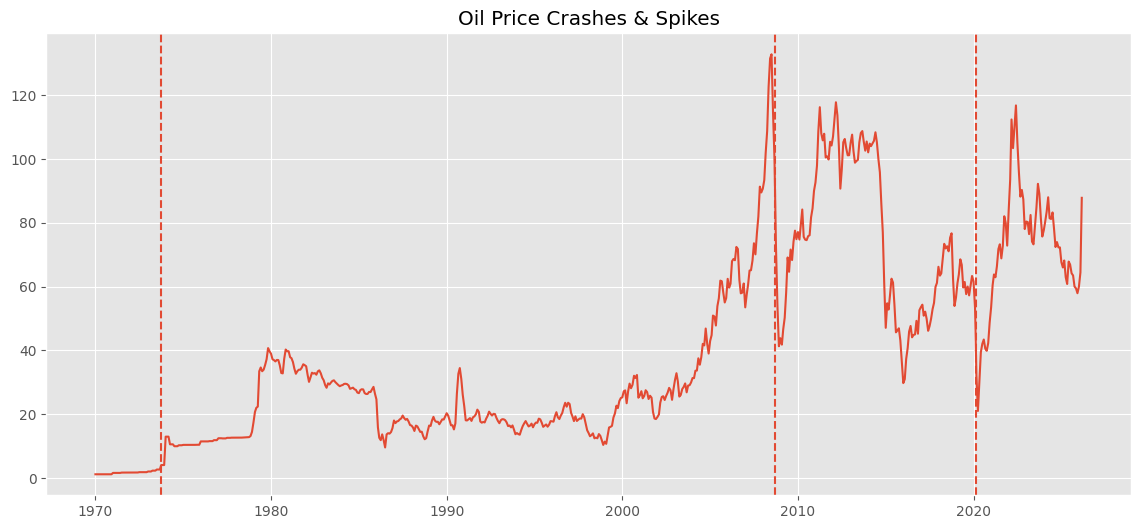

In [ ]:
#plots crashes and spikes in crude oil prices over time and marks important historical events using vertical lines
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Crude_Oil_Price"])
# major events
plt.axvline(pd.to_datetime("1973-10-01"), linestyle="--")
plt.axvline(pd.to_datetime("2008-09-01"), linestyle="--")
plt.axvline(pd.to_datetime("2020-03-01"), linestyle="--")
plt.title("Oil Price Crashes & Spikes")
plt.show()

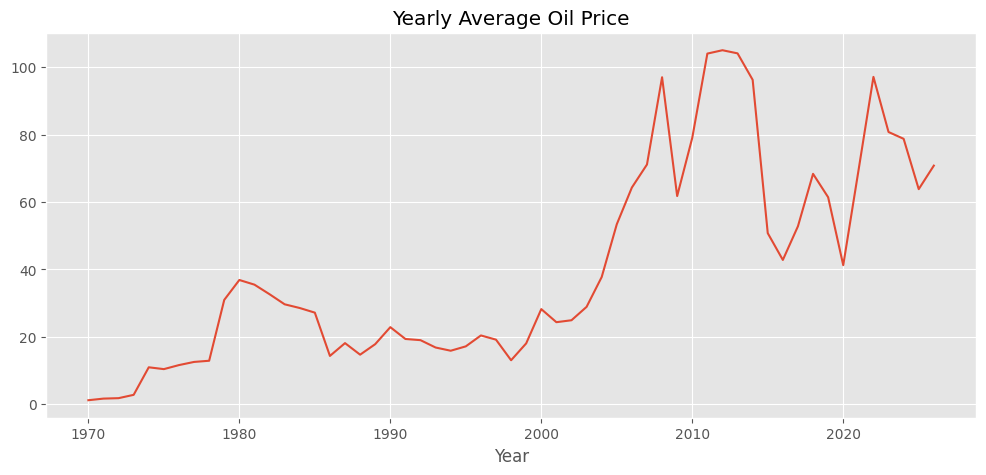

In [ ]:
# Computes average price for each year.
df["Year"] = df["Date"].dt.year
yearly = df.groupby("Year")["Crude_Oil_Price"].mean()
yearly.plot(figsize=(12,5))
plt.title("Yearly Average Oil Price")
plt.show()

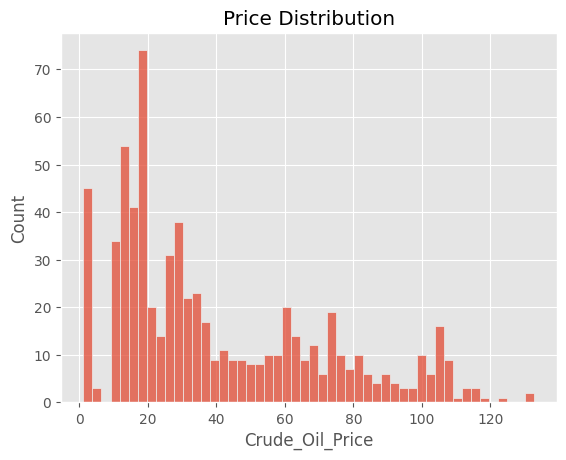

In [ ]:
# Price Distribution
sns.histplot(df["Crude_Oil_Price"], bins=50)
plt.title("Price Distribution")
plt.show()

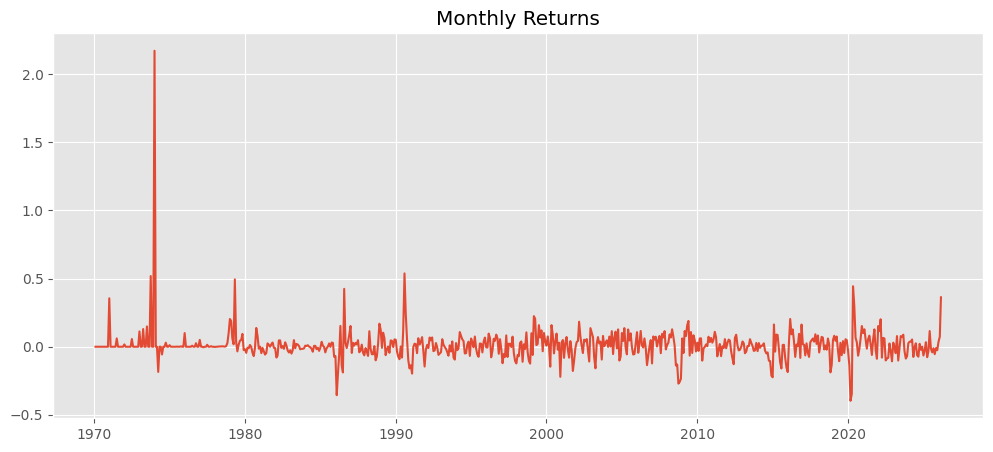

In [40]:
# Calculates and visualizes the monthly returns (percentage changes) in crude oil prices.
df["pct_change"] = df["Crude_Oil_Price"].pct_change()
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["pct_change"])
plt.title("Monthly Returns")
plt.show()

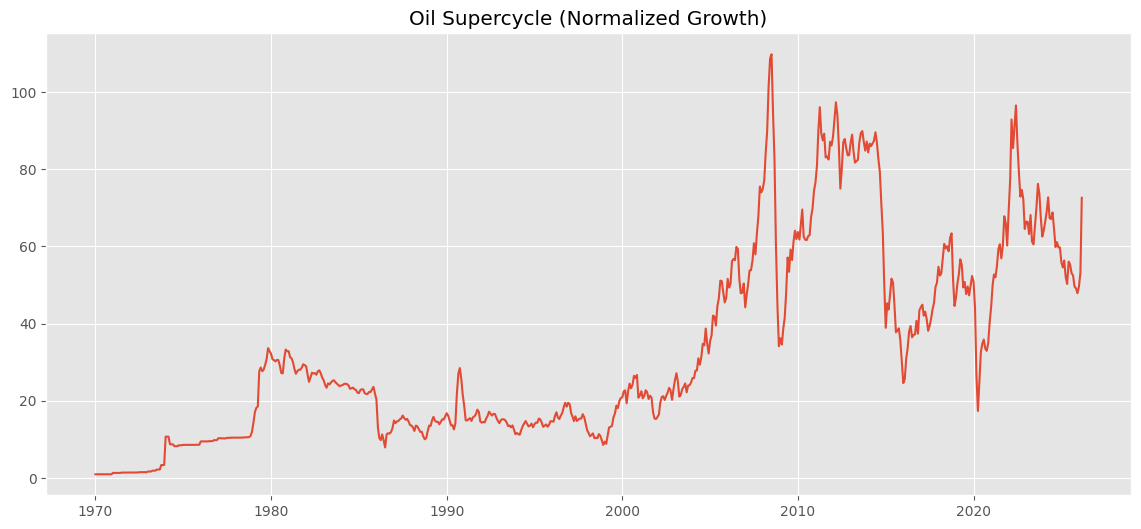

In [ ]:
# Creates a normalized growth chart of crude oil prices to visualize the long-term oil market trend
plt.figure(figsize=(14,6))
normalized = df["Crude_Oil_Price"] / df["Crude_Oil_Price"].iloc[0]
plt.plot(df["Date"], normalized)
plt.title("Oil Supercycle (Normalized Growth)")
plt.show()

In [ ]:
# Applying Linear Regression Model
df_model = df.dropna().copy()
df_model["time"] = np.arange(len(df_model))
X = df_model[["time"]]
y = df_model["Crude_Oil_Price"]
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


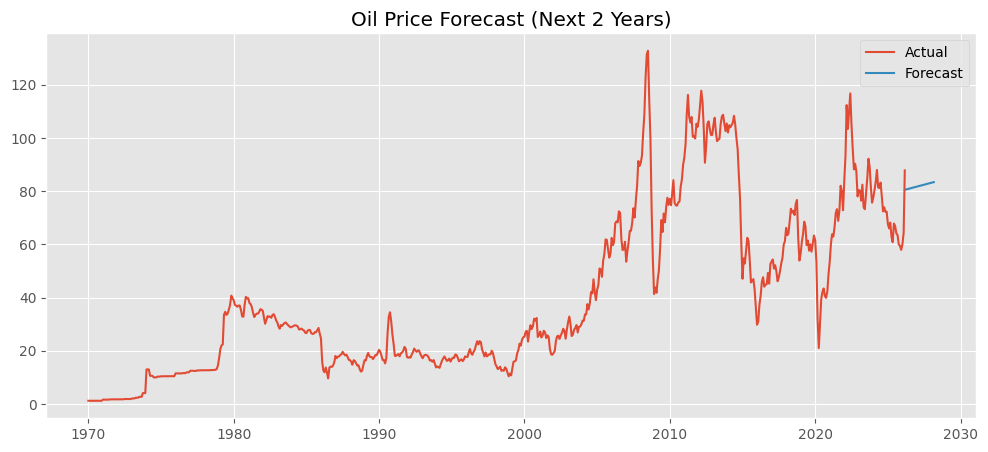

In [41]:
# Prediction to find Oil Price Forecast for Next 2 Years
future = pd.DataFrame({
    "time": np.arange(len(df_model), len(df_model)+24)
})
pred = model.predict(future)
future_dates = pd.date_range(
    df["Date"].iloc[-1],
    periods=24,
    freq="ME"   # ✅ FIXED HERE
)
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Crude_Oil_Price"], label="Actual")
plt.plot(future_dates, pred, label="Forecast")
plt.legend()
plt.title("Oil Price Forecast (Next 2 Years)")
plt.show()

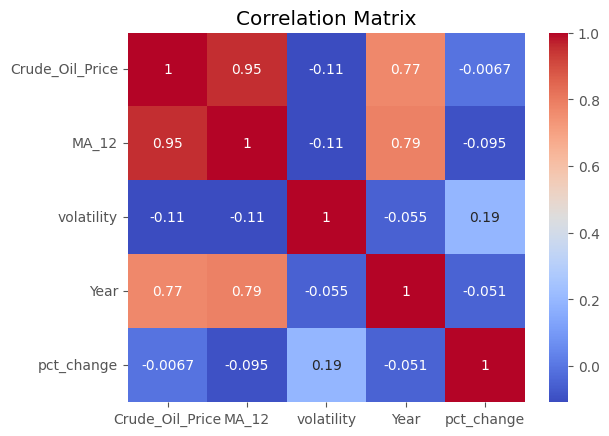

In [42]:
# Correlation Matrix
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()